# Few-Shot Learning using Siamese Networks
This notebook trains and evaluates four architectures (CNN, CNN+Attention, CNN+Mamba, CNN+Attention+Mamba) on the HyperLeaf spectral dataset using Siamese Networks.


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Configure GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("GPU configuration error:", e)

# Parameters
NUM_BANDS = 204
NUM_STATS = 5

# Load dataset
loaded_data = np.load("hyperleaf_processed.npz")
X_data = loaded_data['X']
y_data = loaded_data['y']

# Stratified train/val/test split
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Normalize data
X_min = X_train_raw.min()
X_max = X_train_raw.max()
X_train = (X_train_raw - X_min) / (X_max - X_min + 1e-8)
X_val = (X_val_raw - X_min) / (X_max - X_min + 1e-8)
X_test = (X_test_raw - X_min) / (X_max - X_min + 1e-8)

# Function to generate Siamese pairs
def generate_siamese_pairs(X, y, pairs_to_generate=10000):
    pair_left, pair_right, labels = [], [], []
    class_indices = {c: np.where(y == c)[0] for c in np.unique(y)}
    classes = list(class_indices.keys())
    for _ in range(pairs_to_generate):
        if np.random.rand() > 0.5:
            current_class = np.random.choice(classes)
            idx1, idx2 = np.random.choice(class_indices[current_class], size=2, replace=False)
            pair_left.append(X[idx1])
            pair_right.append(X[idx2])
            labels.append(1.0)
        else:
            class1, class2 = np.random.choice(classes, size=2, replace=False)
            idx1 = np.random.choice(class_indices[class1])
            idx2 = np.random.choice(class_indices[class2])
            pair_left.append(X[idx1])
            pair_right.append(X[idx2])
            labels.append(0.0)
    return [np.array(pair_left), np.array(pair_right)], np.array(labels)

X_train_pairs, y_train_pairs = generate_siamese_pairs(X_train, y_train, pairs_to_generate=15000)
X_val_pairs, y_val_pairs = generate_siamese_pairs(X_val, y_val, pairs_to_generate=3000)

BATCH_SIZE = 64
train_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_train_pairs[0], X_train_pairs[1]), y_train_pairs)
).shuffle(buffer_size=len(y_train_pairs)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_val_pairs[0], X_val_pairs[1]), y_val_pairs)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Helper function to compile Siamese model
def build_siamese_model(encoder, learning_rate=2e-4):
    input_left = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    input_right = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    encoded_left = encoder(input_left)
    encoded_right = encoder(input_right)
    l1_distance = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([encoded_left, encoded_right])
    prediction = layers.Dense(1, activation='sigmoid')(l1_distance)
    siamese = models.Model(inputs=[input_left, input_right], outputs=prediction)
    siamese.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return siamese


In [6]:
# --- 1. CNN Architecture ---
def build_cnn_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Encoder")

cnn_encoder = build_cnn_encoder()
siamese_cnn = build_siamese_model(cnn_encoder)

checkpoint_cnn = tf.keras.callbacks.ModelCheckpoint(
    "best_siamese_cnn.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

print("Training CNN Siamese...")
history_cnn = siamese_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[checkpoint_cnn],
    verbose=1
)


Training CNN Siamese...
Epoch 1/150
235/235 [==============================] - ETA: 0s - loss: 0.7105 - accuracy: 0.5606
Epoch 1: val_accuracy improved from -inf to 0.48400, saving model to best_siamese_cnn.keras
235/235 [==============================] - 7s 22ms/step - loss: 0.7105 - accuracy: 0.5606 - val_loss: 0.7253 - val_accuracy: 0.4840
Epoch 2/150
235/235 [==============================] - ETA: 0s - loss: 0.6304 - accuracy: 0.6960
Epoch 2: val_accuracy improved from 0.48400 to 0.65833, saving model to best_siamese_cnn.keras
235/235 [==============================] - 5s 20ms/step - loss: 0.6304 - accuracy: 0.6960 - val_loss: 0.6375 - val_accuracy: 0.6583
Epoch 3/150
233/235 [============================>.] - ETA: 0s - loss: 0.5895 - accuracy: 0.7260
Epoch 3: val_accuracy did not improve from 0.65833
235/235 [==============================] - 5s 21ms/step - loss: 0.5895 - accuracy: 0.7258 - val_loss: 0.7128 - val_accuracy: 0.6047
Epoch 4/150
233/235 [============================>.

In [7]:
# --- 2. CNN + Attention Architecture ---
def build_cnn_attention_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    
    # Attention Block
    attn_out = layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.05)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Attention_Encoder")

cnn_attention_encoder = build_cnn_attention_encoder()
siamese_cnn_attention = build_siamese_model(cnn_attention_encoder)

checkpoint_attention = tf.keras.callbacks.ModelCheckpoint(
    "best_siamese_cnn_attention.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

print("Training CNN+Attention Siamese...")
history_attention = siamese_cnn_attention.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[checkpoint_attention],
    verbose=1
)


Training CNN+Attention Siamese...
Epoch 1/150
234/235 [============================>.] - ETA: 0s - loss: 0.7247 - accuracy: 0.5075
Epoch 1: val_accuracy improved from -inf to 0.54733, saving model to best_siamese_cnn_attention.keras
235/235 [==============================] - 11s 31ms/step - loss: 0.7247 - accuracy: 0.5074 - val_loss: 0.7199 - val_accuracy: 0.5473
Epoch 2/150
234/235 [============================>.] - ETA: 0s - loss: 0.6570 - accuracy: 0.6504
Epoch 2: val_accuracy improved from 0.54733 to 0.57500, saving model to best_siamese_cnn_attention.keras
235/235 [==============================] - 7s 30ms/step - loss: 0.6570 - accuracy: 0.6507 - val_loss: 0.6928 - val_accuracy: 0.5750
Epoch 3/150
234/235 [============================>.] - ETA: 0s - loss: 0.6005 - accuracy: 0.7182
Epoch 3: val_accuracy improved from 0.57500 to 0.71533, saving model to best_siamese_cnn_attention.keras
235/235 [==============================] - 7s 30ms/step - loss: 0.6005 - accuracy: 0.7182 - val_lo

In [3]:
# --- 3. CNN + Mamba Architecture ---
class StableMambaBlock(layers.Layer):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(expand * d_model)

    def build(self, input_shape):
        self.in_proj = layers.Dense(self.d_inner * 2, use_bias=False)
        self.conv1d = layers.Conv1D(
            filters=self.d_inner, kernel_size=self.d_conv, padding='same', groups=self.d_inner, activation='swish'
        )
        self.x_proj = layers.Dense(self.d_state * 2 + self.d_inner, use_bias=False)
        self.dt_proj = layers.Dense(self.d_inner, activation='softplus')
        
        A_init_val = -np.log(np.arange(1, self.d_state + 1, dtype=np.float32))
        A_init_val = np.tile(A_init_val[np.newaxis, :], (self.d_inner, 1))
        A_init = tf.keras.initializers.Constant(A_init_val)
        self.A = self.add_weight(
            name="A",
            shape=(self.d_inner, self.d_state),
            initializer=A_init,
            trainable=True
        )
        
        self.D = self.add_weight(
            name="D",
            shape=(self.d_inner,),
            initializer=tf.keras.initializers.Ones(),
            trainable=True
        )
        
        self.out_proj = layers.Dense(self.d_model, use_bias=False)
        super().build(input_shape)

    def call(self, x):
        projected = self.in_proj(x)
        x_branch, res_branch = tf.split(projected, num_or_size_splits=2, axis=-1)
        x_branch = self.conv1d(x_branch)
        
        ssm_params = self.x_proj(x_branch)
        B, C, delta = tf.split(ssm_params, [self.d_state, self.d_state, self.d_inner], axis=-1)
        delta = self.dt_proj(delta)
        
        delta_expanded = tf.expand_dims(delta, axis=-1)
        A_expanded = tf.expand_dims(self.A, axis=0)
        A_expanded = tf.expand_dims(A_expanded, axis=0)
        
        A_bar = tf.exp(delta_expanded * A_expanded)
        
        B_expanded = tf.expand_dims(B, axis=2)
        B_bar = delta_expanded * B_expanded
        
        x_branch_expanded = tf.expand_dims(x_branch, axis=-1)
        inputs_ssm = B_bar * x_branch_expanded
        
        inputs_ssm = tf.transpose(inputs_ssm, perm=[1, 0, 2, 3])
        A_bar = tf.transpose(A_bar, perm=[1, 0, 2, 3])
        
        elems = (A_bar, inputs_ssm)
        batch_size = tf.shape(x)[0]
        h_0 = tf.zeros((batch_size, self.d_inner, self.d_state), dtype=tf.float32)
        
        def scan_fn(h_prev, elem):
            a_bar_t, ssm_in_t = elem
            return a_bar_t * h_prev + ssm_in_t
        
        h_seq = tf.scan(scan_fn, elems, initializer=h_0)
        h_seq = tf.transpose(h_seq, perm=[1, 0, 2, 3])
        
        C_expanded = tf.expand_dims(C, axis=2)
        y = tf.reduce_sum(h_seq * C_expanded, axis=-1)
        
        D_expanded = tf.reshape(self.D, (1, 1, self.d_inner))
        y = y + D_expanded * x_branch
        
        gated_output = y * tf.keras.activations.swish(res_branch)
        return self.out_proj(gated_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "d_state": self.d_state,
            "d_conv": self.d_conv,
            "expand": self.expand
        })
        return config

def build_cnn_mamba_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    # Mamba block
    mamba_out = StableMambaBlock(d_model=128, d_state=16, d_conv=4, expand=2)(x)
    x = layers.Add()([x, mamba_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Mamba_Encoder")

cnn_mamba_encoder = build_cnn_mamba_encoder()
siamese_cnn_mamba = build_siamese_model(cnn_mamba_encoder)

checkpoint_mamba = tf.keras.callbacks.ModelCheckpoint(
    "best_siamese_cnn_mamba.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

print("Training CNN+Mamba Siamese...")
history_mamba = siamese_cnn_mamba.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[checkpoint_mamba],
    verbose=1
)


Training CNN+Mamba Siamese...
Epoch 1/150
235/235 [==============================] - ETA: 0s - loss: 0.7216 - accuracy: 0.4985
Epoch 1: val_accuracy improved from -inf to 0.51400, saving model to best_siamese_cnn_mamba.keras
235/235 [==============================] - 61s 227ms/step - loss: 0.7216 - accuracy: 0.4985 - val_loss: 0.7165 - val_accuracy: 0.5140
Epoch 2/150
235/235 [==============================] - ETA: 0s - loss: 0.7148 - accuracy: 0.4981
Epoch 2: val_accuracy did not improve from 0.51400
235/235 [==============================] - 52s 222ms/step - loss: 0.7148 - accuracy: 0.4981 - val_loss: 0.7125 - val_accuracy: 0.5140
Epoch 3/150
235/235 [==============================] - ETA: 0s - loss: 0.7113 - accuracy: 0.5053
Epoch 3: val_accuracy did not improve from 0.51400
235/235 [==============================] - 50s 211ms/step - loss: 0.7113 - accuracy: 0.5053 - val_loss: 0.7097 - val_accuracy: 0.5140
Epoch 4/150
235/235 [==============================] - ETA: 0s - loss: 0.7089

In [4]:
# --- 4. CNN + Attention + Mamba Architecture ---
def build_cnn_attention_mamba_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    # Attention block
    attn_out = layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.05)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    
    # Mamba block
    mamba_out = StableMambaBlock(d_model=128, d_state=16, d_conv=4, expand=2)(x)
    x = layers.Add()([x, mamba_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Attention_Mamba_Encoder")

cnn_attention_mamba_encoder = build_cnn_attention_mamba_encoder()
siamese_cnn_attention_mamba = build_siamese_model(cnn_attention_mamba_encoder)

checkpoint_attn_mamba = tf.keras.callbacks.ModelCheckpoint(
    "best_siamese_cnn_attention_mamba.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

print("Training CNN+Attention+Mamba Siamese...")
history_attn_mamba = siamese_cnn_attention_mamba.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[checkpoint_attn_mamba],
    verbose=1
)


Training CNN+Attention+Mamba Siamese...
Epoch 1/150
180/235 [=====================>........] - ETA: 13s - loss: 0.7229 - accuracy: 0.4997

KeyboardInterrupt: 

In [8]:
# --- 5. Testing Cell (Holdout Evaluation) ---
# 5-Shot Holdout Evaluation over 100 trials for each model
unique_classes = np.unique(y_train)
train_class_indices = {c: np.where(y_train == c)[0] for c in unique_classes}

encoders = {
    'CNN': cnn_encoder,
    'CNN+Attention': cnn_attention_encoder,
    'CNN+Mamba': cnn_mamba_encoder
    ,'CNN+Attention+Mamba': cnn_attention_mamba_encoder
}

eval_results = {}

for name, encoder in encoders.items():
    print(f"\nEvaluating {name} Encoder...")
    suffix = name.lower().replace('+', '_')
    try:
        encoder.load_weights(f"best_siamese_{suffix}.keras", by_name=True, skip_mismatch=True)
    except Exception as e:
        print(f"No saved weights found for {name}, using current weights.")
        
    test_embeddings = encoder.predict(X_test, verbose=0)
    train_embeddings = encoder.predict(X_train, verbose=0)
    
    trial_accs = []
    for trial in range(100):
        np.random.seed(trial)
        prototypes = {}
        for c in unique_classes:
            chosen_idx = np.random.choice(train_class_indices[c], 5, replace=False)
            prototypes[c] = np.mean(train_embeddings[chosen_idx], axis=0)
        
        preds = []
        for sample_emb in test_embeddings:
            dists = {c: np.linalg.norm(sample_emb - prototypes[c]) for c in prototypes}
            preds.append(min(dists, key=dists.get))
        
        acc = np.mean(np.array(preds) == y_test) * 100
        trial_accs.append(acc)
    
    mean_acc = np.mean(trial_accs)
    max_acc = np.max(trial_accs)
    min_acc = np.min(trial_accs)
    eval_results[name] = trial_accs
    
    print(f"5-Shot Holdout Test Accuracy over 100 trials:")
    print(f"  Mean Accuracy: {mean_acc:.2f}%")
    print(f"  Max Accuracy:  {max_acc:.2f}%")
    print(f"  Min Accuracy:  {min_acc:.2f}%")



Evaluating CNN Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 77.71%
  Max Accuracy:  80.50%
  Min Accuracy:  64.78%

Evaluating CNN+Attention Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 92.99%
  Max Accuracy:  93.71%
  Min Accuracy:  92.45%

Evaluating CNN+Mamba Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 85.98%
  Max Accuracy:  86.79%
  Min Accuracy:  84.91%

Evaluating CNN+Attention+Mamba Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 49.35%
  Max Accuracy:  60.38%
  Min Accuracy:  35.22%


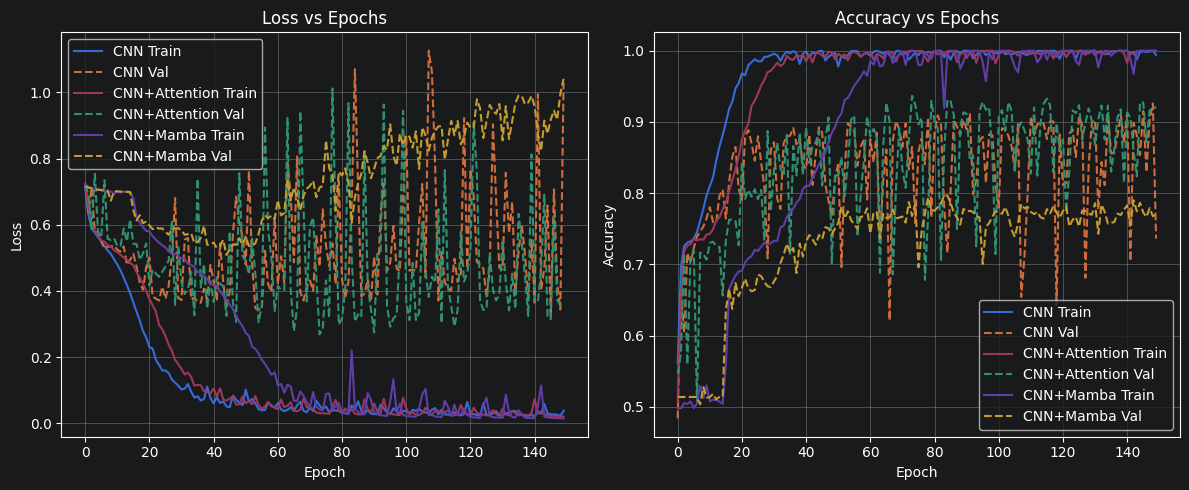

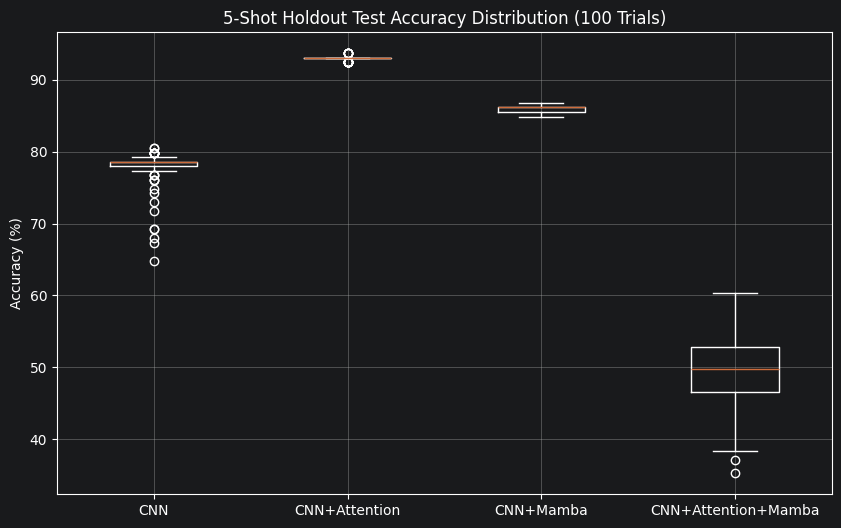

In [9]:
# --- 6. Plotting Cell ---
import pandas as pd
# Plotting training curves and evaluation results
histories = {
    'CNN': (loss_cnn, acc_cnn) if 'loss_cnn' in locals() else None,
    'CNN+Attention': (loss_attention, acc_attention) if 'loss_attention' in locals() else None,
    'CNN+Mamba': (loss_mamba, acc_mamba) if 'loss_mamba' in locals() else None,
    'CNN+Attention+Mamba': (loss_attn_mamba, acc_attn_mamba) if 'loss_attn_mamba' in locals() else None
}

def smooth(y, window=50):
    return pd.Series(y).rolling(window, min_periods=1).mean()

# 1. Loss vs Episode
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, hist in histories.items():
    if hist:
        plt.plot(hist[0], alpha=0.3)
        plt.plot(smooth(hist[0]), label=f'{name}')
plt.title('Loss vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy vs Episode
plt.subplot(1, 2, 2)
for name, hist in histories.items():
    if hist:
        plt.plot(hist[1], alpha=0.3)
        plt.plot(smooth(hist[1]), label=f'{name}')
plt.title('Accuracy vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Holdout Evaluation Distributions
if eval_results:
    plt.figure(figsize=(10, 6))
    data_to_plot = [eval_results[name] for name in eval_results]
    plt.boxplot(data_to_plot, tick_labels=list(eval_results.keys()))
    plt.title('5-Shot Holdout Test Accuracy Distribution (100 Trials)')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.show()
